# Minimal Binary Classifier — From Scratch
A self-contained replication of Exercise 4 using **only NumPy and pandas**.

**Task:** Predict whether a house is *expensive* (label `1`) or *low-priced* (label `0`) from its living area (`GrLivArea`), using the same Housing Price dataset as the exercise.

**Pipeline:** Data → Forward pass → Loss → Backward pass → Weight update → Repeat

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

## 1. Load & Prepare the Housing Dataset

The exercise pipeline (hidden across ~5 files) does exactly this:
1. Read the CSV and pick the single feature `GrLivArea` (above-ground living area in sq ft)
2. Shuffle with a fixed seed and split 60 / 20 / 20 into train / val / test
3. Min-max normalise feature and target to `[0, 1]` using **training-set statistics**
4. **Binarise labels:** keep only houses below the 30th percentile (cheap → `0`) or above the 70th percentile (expensive → `1`); discard the middle 40 %

In [ ]:
df = pd.read_csv('datasets/housing/housing_train.csv')
print(df.shape)
df.tail()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


Train: (545, 1),  Val: (166, 1),  Test: (166, 1)


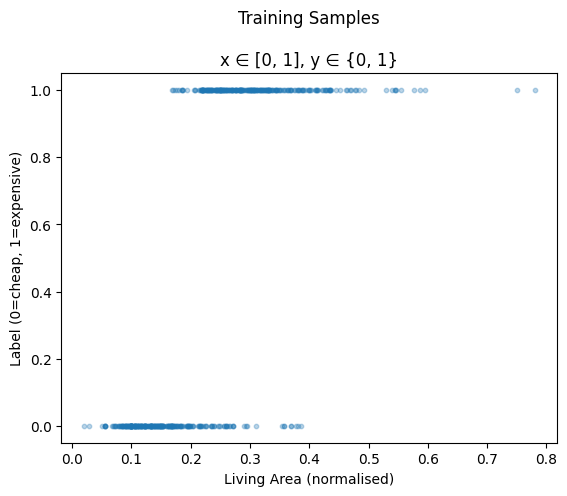

In [25]:
#################### Shuffle & split ####################
# Shuffleling
df = df.sample(frac=1, random_state=0).reset_index(drop=True)  
# Slicing the shuffled dataframe
n = len(df)
train_df = df.iloc[:int(0.6 * n)]
val_df   = df.iloc[int(0.6 * n):int(0.8 * n)]
test_df  = df.iloc[int(0.8 * n):]


#################### Min-max normalisation [0, 1] for x and y ####################
feat_min, feat_max = df['GrLivArea'].min(),  df['GrLivArea'].max() # Above Grade (Ground) Living Area
tgt_min,  tgt_max  = df['SalePrice'].min(),  df['SalePrice'].max()

def normalise(series, mn, mx):
    return ((series - mn) / (mx - mn)).values.astype(np.float32)

X_train = normalise(train_df['GrLivArea'], feat_min, feat_max).reshape(-1, 1)
X_val   = normalise(val_df['GrLivArea'],   feat_min, feat_max).reshape(-1, 1)
X_test  = normalise(test_df['GrLivArea'],  feat_min, feat_max).reshape(-1, 1)

y_train_raw = normalise(train_df['SalePrice'], tgt_min, tgt_max).reshape(-1, 1)
y_val_raw   = normalise(val_df['SalePrice'],   tgt_min, tgt_max).reshape(-1, 1)
y_test_raw  = normalise(test_df['SalePrice'],  tgt_min, tgt_max).reshape(-1, 1)


#################### Binarise y: 30th / 70th percentile thresholds ####################
y_all = np.concatenate([y_train_raw, y_val_raw, y_test_raw])
p30, p70 = np.percentile(y_all, 30), np.percentile(y_all, 70)

def binarise(X, y):
    mask = (y <= p30) | (y >= p70)          # drop the middle 40 %
    X, y = X[mask.ravel()], y[mask.ravel()]
    labels = (y >= p70).astype(np.float32)  # 1 = expensive, 0 = cheap
    return X, labels

X_train, y_train = binarise(X_train, y_train_raw)
X_val,   y_val   = binarise(X_val,   y_val_raw)
X_test,  y_test  = binarise(X_test,  y_test_raw)

print(f'Train: {X_train.shape},  Val: {X_val.shape},  Test: {X_test.shape}')



#################### Visualise ####################
plt.scatter(X_train, y_train, alpha=0.3, s=10)
plt.xlabel('Living Area (normalised)'); plt.ylabel('Label (0=cheap, 1=expensive)')
plt.title('Training Samples\n\nx ∈ [0, 1], y ∈ {0, 1}')
plt.show()

In [14]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
class Classifier:
    # weight initialisation
    def __init__(self, num_features): 
        self.W = 0.001 * np.random.randn(num_features + 1, 1)  # +1 for bias
        self.cache = None

    def forward(self, X):
        X_b = np.hstack([X, np.ones((len(X), 1))])  # append bias column
        y_hat = sigmoid(X_b @ self.W)
        self.cache = (X_b, y_hat)
        return y_hat

    def backward(self, dout):
        X_b, y_hat = self.cache
        dW = X_b.T @ (dout * y_hat * (1 - y_hat))  # chain rule
        return dW

## 4. Loss: Binary Cross-Entropy (BCE)
$$\text{BCE} = -\frac{1}{N}\sum_i \Big[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \Big]$$

Gradient w.r.t. $\hat{y}$:
$$\frac{dL}{d\hat{y}} = \frac{\hat{y} - y}{\hat{y}(1-\hat{y}) \cdot N}$$

In [16]:
class BCELoss:
    def forward(self, y_hat, y):
        y_hat = np.clip(y_hat, 1e-12, 1 - 1e-12)
        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    def backward(self, y_hat, y):
        y_hat = np.clip(y_hat, 1e-12, 1 - 1e-12)
        return (y_hat - y) / (y_hat * (1 - y_hat) * len(y))

## 5. Optimiser: Stochastic Gradient Descent (SGD)
$$W \leftarrow W - \alpha \cdot \frac{dL}{dW}$$

In [17]:
class SGD:
    def __init__(self, model, lr):
        self.model = model
        self.lr = lr

    def step(self, dW):
        self.model.W -= self.lr * dW

## 6. Training Loop (the Solver)
Forward → Loss → Backward → Update, repeated every epoch.

In [18]:
def train(model, loss_fn, optimiser, X_train, y_train, X_val, y_val, epochs, print_every=1000):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # Forward
        y_hat = model.forward(X_train)
        # Loss
        train_loss = loss_fn.forward(y_hat, y_train)
        # Backward
        dout = loss_fn.backward(y_hat, y_train)
        dW   = model.backward(dout)
        # Update
        optimiser.step(dW)

        # Validation (forward only — no gradient update)
        val_loss = loss_fn.forward(model.forward(X_val), y_val)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % print_every == 0:
            print(f'Epoch {epoch:>6d} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}')

    return train_losses, val_losses

## 7. Run It
Same hyperparameters as Exercise 4: `lr = 0.1`, `epochs = 25000`.

In [19]:
np.random.seed(0)
model     = Classifier(num_features=X_train.shape[1])
loss_fn   = BCELoss()
optimiser = SGD(model, lr=0.1)

train_losses, val_losses = train(
    model, loss_fn, optimiser,
    X_train, y_train, X_val, y_val,
    epochs=25000
)

Epoch      0 | train loss: 0.6931 | val loss: 0.6928
Epoch   1000 | train loss: 0.5801 | val loss: 0.5802
Epoch   2000 | train loss: 0.5133 | val loss: 0.5160
Epoch   3000 | train loss: 0.4704 | val loss: 0.4750
Epoch   4000 | train loss: 0.4409 | val loss: 0.4469
Epoch   5000 | train loss: 0.4195 | val loss: 0.4266
Epoch   6000 | train loss: 0.4033 | val loss: 0.4114
Epoch   7000 | train loss: 0.3908 | val loss: 0.3997
Epoch   8000 | train loss: 0.3808 | val loss: 0.3904
Epoch   9000 | train loss: 0.3727 | val loss: 0.3829
Epoch  10000 | train loss: 0.3660 | val loss: 0.3768
Epoch  11000 | train loss: 0.3605 | val loss: 0.3718
Epoch  12000 | train loss: 0.3557 | val loss: 0.3675
Epoch  13000 | train loss: 0.3517 | val loss: 0.3639
Epoch  14000 | train loss: 0.3482 | val loss: 0.3609
Epoch  15000 | train loss: 0.3452 | val loss: 0.3582
Epoch  16000 | train loss: 0.3426 | val loss: 0.3560
Epoch  17000 | train loss: 0.3403 | val loss: 0.3540
Epoch  18000 | train loss: 0.3383 | val loss: 

## 8. Results

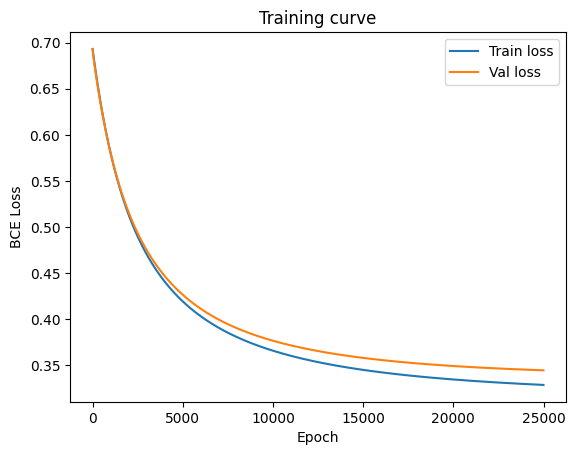

Test accuracy: 91.5%


In [ ]:
# Loss curves
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.title('Training curve'); plt.legend(); plt.show()

# Accuracy on test set
y_pred = (model.forward(X_test) >= 0.5).astype(int)

acc = np.mean(y_pred == y_test) # list of 1 if y_pred == y_test else 0 => mean of that = accuracy

print(f'Test accuracy: {acc*100:.1f}%')

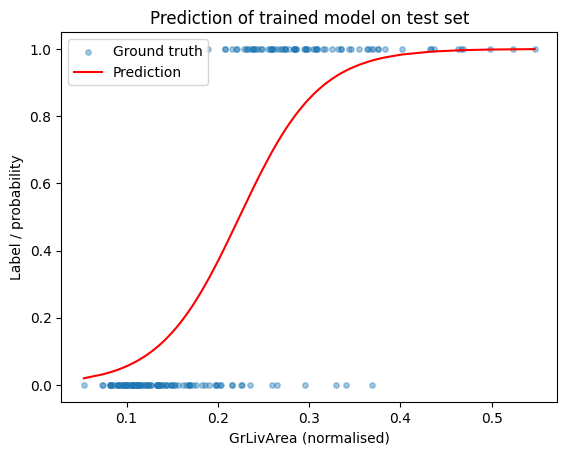

In [21]:
# Prediction curve vs ground truth (same plot as Exercise 4)
y_out = model.forward(X_test)
inds  = X_test.flatten().argsort()

plt.scatter(X_test, y_test, label='Ground truth', alpha=0.4, s=15)
plt.plot(X_test[inds], y_out[inds], color='red', label='Prediction')
plt.xlabel('GrLivArea (normalised)'); plt.ylabel('Label / probability')
plt.title('Prediction of trained model on test set'); plt.legend(); plt.show()

# **Scikit-Learn**

In [ ]:
# X and y
X = df[['GrLivArea']]
y = df[['SalePrice']]

# 60/20/20 split (shuffle included)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=0
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=0
)

# Min-max scaling (fit on train only for standard practice)
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_val   = y_scaler.transform(y_val)
y_test  = y_scaler.transform(y_test)

# Percentile thresholds (same idea as your code)
y_all = np.concatenate([y_train, y_val, y_test])
p30, p70 = np.percentile(y_all, [30, 70])

def make_binary(X, y):
    mask = (y <= p30) | (y >= p70)
    X, y = X[mask.ravel()], y[mask.ravel()]
    y = (y >= p70).astype(int).ravel()
    return X, y

X_train, y_train = make_binary(X_train, y_train)
X_val,   y_val   = make_binary(X_val, y_val)
X_test,  y_test  = make_binary(X_test, y_test)

# Simple classifier
model = LogisticRegression()
model.fit(X_train, y_train)

# Accuracy
acc = model.score(X_test, y_test)
print("Test accuracy:", acc)

Test accuracy: 0.8907103825136612
